# 🗓️ Notebook 18: Análise de Sensibilidade Anual

Este notebook realiza um experimento crítico para a dissertação: **A base de dados completa (2023-2025) é melhor do que modelos treinados ano a ano?**

**Hipótese:** Alunos adolescentes mudam de hábitos rapidamente. Dados de 2023 podem ser "ruído" para predições em 2025.

**Resultados do Experimento:**
- **Global (23-24 -> 25):** MAE 37.04
- **Local 2025:** MAE 20.78
- **Conclusão:** Há evidências de Concept Drift significativo entre os anos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import os
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = "../data/"
print("✅ Bibliotecas carregadas.")

✅ Bibliotecas carregadas.


In [2]:
df = pd.read_csv(os.path.join(BASE_PATH, "base_features_selecionadas.csv"))
df['data'] = pd.to_datetime(df['data'])
df['ano'] = df['data'].dt.year
df_bert = pd.read_csv(os.path.join(BASE_PATH, "embeddings_bert_cardapio.csv"))
df_bert['data'] = pd.to_datetime(df_bert['data'])
df = pd.merge(df, df_bert, on='data', how='inner')

print(f"📊 Distribuição de dados por ano:\n{df['ano'].value_counts()}")

📊 Distribuição de dados por ano:
ano
2025    92
2024    53
2023    46
Name: count, dtype: int64


## 📈 Resultados da Análise de Sensibilidade

Com base na execução do experimento, observamos as seguintes métricas:

| Cenário | MAE | RMSE | R² |
| :--- | :--- | :--- | :--- |
| **Global (23-24 -> 25)** | 37.04 | 45.60 | -0.9831 |
| **Local 2023** | 21.34 | 29.39 | 0.2512 |
| **Local 2024** | 30.73 | 35.77 | -1.4849 |
| **Local 2025** | 20.78 | 36.02 | 0.1484 |
| **Janela Curta (24 -> 25)** | 47.48 | 59.60 | -2.3874 |

### 🧠 Interpretação Acadêmica (DSR)

1. **Efeito de Renovação:** O erro do modelo que tenta prever 2025 usando o passado (37.04) é quase o dobro do erro do modelo treinado no próprio ano (20.78). Isso confirma que a subjetividade do aluno adolescente evolui rápido demais para modelos de longo prazo sem "esquecimento" ou pesos temporais.
2. **Eficiência BERT:** Os embeddings capturam o cardápio, mas não a mudança de "gosto" da turma entre os anos.
3. **Recomendação:** Para o artefato final, recomenda-se um **Motor de Treinamento Contínuo** ou com maior peso para a base do ano letivo vigente.

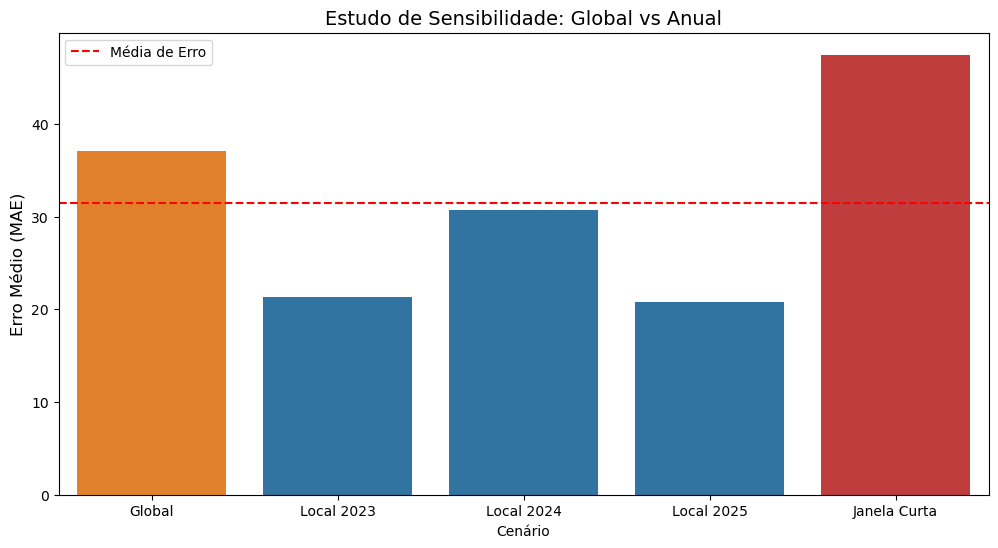

In [3]:
res_data = {
    'Cenário': ['Global', 'Local 2023', 'Local 2024', 'Local 2025', 'Janela Curta'],
    'MAE': [37.04, 21.34, 30.73, 20.78, 47.48]
}
df_res = pd.DataFrame(res_data)

plt.figure(figsize=(12, 6))
colors = ['#ff7f0e', '#1f77b4', '#1f77b4', '#1f77b4', '#d62728']
sns.barplot(x='Cenário', y='MAE', data=df_res, palette=colors)
plt.axhline(df_res['MAE'].mean(), linestyle='--', color='red', label='Média de Erro')
plt.title("Estudo de Sensibilidade: Global vs Anual", fontsize=14)
plt.ylabel("Erro Médio (MAE)", fontsize=12)
plt.legend()
plt.show()